# **Import Neccesary Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
plt.figure(figsize=(12,6))
sns.set_style('whitegrid')
print("Libraries Loaded!!")

Libraries Loaded!!


<Figure size 1200x600 with 0 Axes>

# **EDA**

## *Load The Data*

In [3]:
df = pd.read_csv("C:\\Users\\abhay\\OneDrive\\Desktop\\ML learning\\Linear Regression\\Gym Calories\\Data\\gym_calories.csv")
print("Data Loaded")

Data Loaded


## *Data Exploration*

In [4]:
print(f"The Given Data have {df.shape} shape")

The Given Data have (521, 7) shape


In [5]:
#First 5 Rows
df.head()

,age,weight_kg,workout_duration_min,avg_heart_rate,workout_intensity,water_intake_liters,calories_burned
0,22.0,110.5,53.0,119.0,4.0,2.9,565.7
1,49.0,111.5,52.0,98.0,8.0,4.0,549.8
2,23.0,45.8,58.0,154.0,1.0,3.7,492.1
3,47.0,111.5,65.0,148.0,8.0,3.0,656.4
4,-8.0,65.4,111.0,153.0,8.0,0.9,742.6


In [6]:
#Last 5 Rows
df.tail()

,age,weight_kg,workout_duration_min,avg_heart_rate,workout_intensity,water_intake_liters,calories_burned
516,58.0,101.8,90.0,93.0,1.0,2.5,599.2
517,-8.0,65.4,111.0,153.0,8.0,0.9,742.6
518,46.0,73.6,27.0,109.0,3.0,2.7,385.2
519,59.0,108.0,90.0,136.0,7.0,1.6,709.2
520,46.0,64.9,105.0,96.0,2.0,2.0,603.5


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   521 non-null    float64
 1   weight_kg             521 non-null    float64
 2   workout_duration_min  521 non-null    float64
 3   avg_heart_rate        501 non-null    float64
 4   workout_intensity     521 non-null    float64
 5   water_intake_liters   505 non-null    float64
 6   calories_burned       521 non-null    float64
dtypes: float64(7)
memory usage: 28.6 KB


In [8]:
df.describe()

,age,weight_kg,workout_duration_min,avg_heart_rate,workout_intensity,water_intake_liters,calories_burned
count,521.000000,521.000000,521.000000,501.000000,521.000000,505.000000,521.000000
mean,40.318618,81.744722,68.030710,134.538922,5.499040,2.271089,601.717658
std,13.876454,22.144357,35.398487,25.583764,2.851535,0.990649,428.062439
min,-8.000000,45.100000,15.000000,90.000000,1.000000,0.500000,320.400000
25%,28.000000,62.600000,41.000000,114.000000,3.000000,1.400000,495.100000
50%,41.000000,81.300000,67.000000,135.000000,6.000000,2.200000,588.000000
75%,51.000000,99.500000,93.000000,155.000000,8.000000,3.100000,670.400000
max,64.000000,119.900000,500.000000,179.000000,10.000000,4.000000,9999.000000


In [9]:
# relationship Between Different Col
df.corr()

,age,weight_kg,workout_duration_min,avg_heart_rate,workout_intensity,water_intake_liters,calories_burned
age,1.000000,0.093430,-0.042670,-0.053502,0.024162,0.008764,-0.018678
weight_kg,0.093430,1.000000,-0.012036,0.021982,-0.053230,0.022160,0.069030
workout_duration_min,-0.042670,-0.012036,1.000000,0.028694,-0.105336,0.018090,0.243102
avg_heart_rate,-0.053502,0.021982,0.028694,1.000000,0.012564,0.029577,0.099638
workout_intensity,0.024162,-0.053230,-0.105336,0.012564,1.000000,-0.042798,0.007138
water_intake_liters,0.008764,0.022160,0.018090,0.029577,-0.042798,1.000000,-0.028007
calories_burned,-0.018678,0.069030,0.243102,0.099638,0.007138,-0.028007,1.000000


In [10]:
# NaN values
print("The NaN values in data is as follows:-")
df.isna().sum()

The NaN values in data is as follows:-


age                      0
weight_kg                0
workout_duration_min     0
avg_heart_rate          20
workout_intensity        0
water_intake_liters     16
calories_burned          0
dtype: int64

In [11]:
# Duplicates in Data
print(f"The duplicates in the Dataset is {df.duplicated().sum()}")

The duplicates in the Dataset is 11


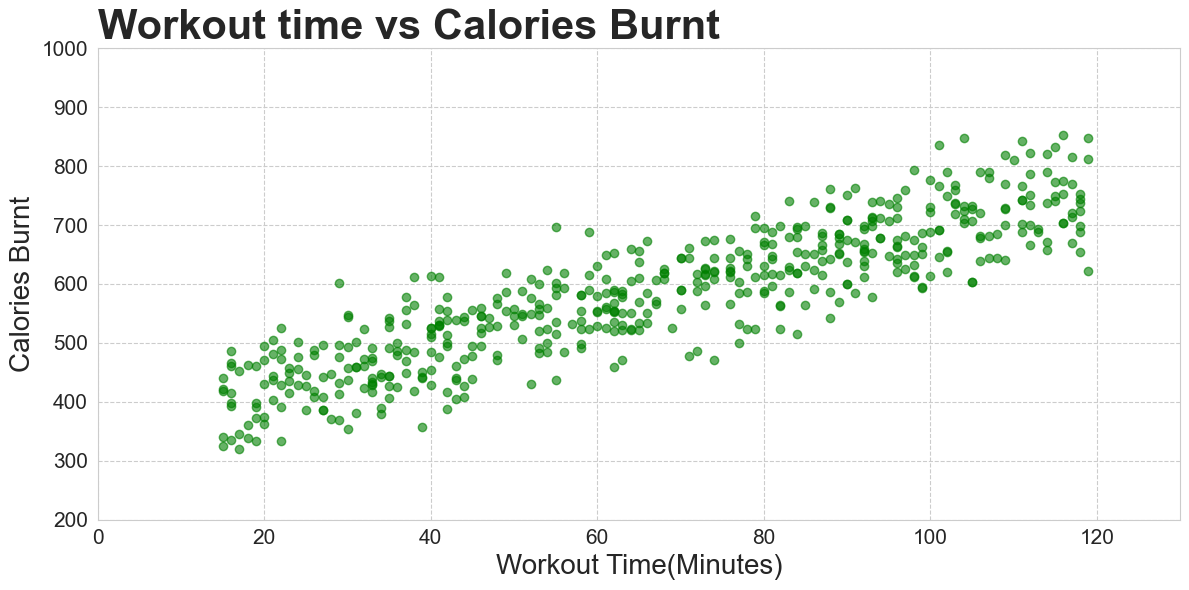

In [12]:
# reationship B/W Calories Burnt And Workout time
plt.figure(figsize=(12,6))
plt.scatter(df['workout_duration_min'],df['calories_burned'],alpha=0.6,color = 'green')
plt.xlim(0,130)
plt.ylim(200,1000)
plt.xlabel("Workout Time(Minutes)",fontsize=20)
plt.ylabel("Calories Burnt",fontsize=20)
plt.title('Workout time vs Calories Burnt',weight = 'bold',fontsize=30,loc='left')
ax = plt.gca()
ax.tick_params('both',labelsize = 15)
plt.grid(visible=True,linestyle='--')
plt.tight_layout()
plt.show()

# **Data Cleaning**

In [13]:
# Create a Copy of Original Data
df_copy = df.copy()

## *Impossible Values*

In [14]:
# finding the values that looks suspecious and replace them with median
df_copy.loc[df_copy['age']<1,'age'] = df_copy['age'].median()
df_copy.loc[df_copy['workout_duration_min']>120,'workout_duration_min'] = df_copy['workout_duration_min'].median()


## *Outliers Handaling*

In [15]:
Q1 = df_copy['calories_burned'].quantile(0.25)
Q3 = df_copy['calories_burned'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_copy.loc[df_copy['calories_burned'] < lower, 'calories_burned'] = np.nan
df_copy.loc[df_copy['calories_burned'] > upper, 'calories_burned'] = np.nan

print("Outliers Handeled")

Outliers Handeled


## *Filling NaN Values*

In [16]:
print("NaN Values Before:- ")
print(df_copy.isna().sum())

df_copy['avg_heart_rate'] = df_copy['avg_heart_rate'].fillna(round(df_copy['avg_heart_rate'].median(),2))
df_copy['water_intake_liters'] = df_copy['water_intake_liters'].fillna(round(df_copy['water_intake_liters'].median(),2))
df_copy['calories_burned'] = df_copy['calories_burned'].fillna(round(df_copy['calories_burned'].median(),2))
print("\nNaN values After:- ")
print(df_copy.isna().sum())

NaN Values Before:- 
age                      0
weight_kg                0
workout_duration_min     0
avg_heart_rate          20
workout_intensity        0
water_intake_liters     16
calories_burned          1
dtype: int64

NaN values After:- 
age                     0
weight_kg               0
workout_duration_min    0
avg_heart_rate          0
workout_intensity       0
water_intake_liters     0
calories_burned         0
dtype: int64


## *Drop Duplicates*

In [17]:
df_copy.drop_duplicates(inplace=True)
print("Duplicates Dropped Successfully")

Duplicates Dropped Successfully


## *Double Check The Clean Data*

In [18]:
print(f"Shape : {df_copy.shape}\n")
print(f"{df_copy.info()}")

Shape : (510, 7)

<class 'pandas.core.frame.DataFrame'>
Index: 510 entries, 0 to 509
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   510 non-null    float64
 1   weight_kg             510 non-null    float64
 2   workout_duration_min  510 non-null    float64
 3   avg_heart_rate        510 non-null    float64
 4   workout_intensity     510 non-null    float64
 5   water_intake_liters   510 non-null    float64
 6   calories_burned       510 non-null    float64
dtypes: float64(7)
memory usage: 31.9 KB
None


# **Visual**

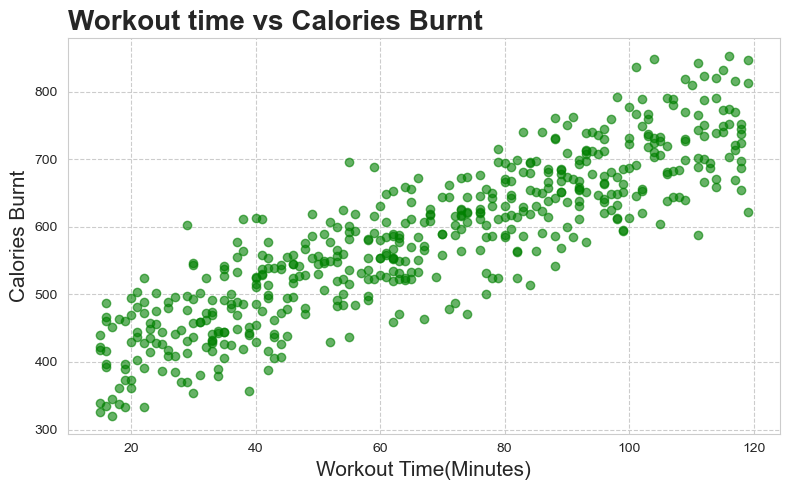

In [19]:
plt.figure(figsize=(8,5))
plt.scatter(df_copy['workout_duration_min'],df_copy['calories_burned'],alpha=0.6,color = 'green')
plt.xlabel("Workout Time(Minutes)",fontsize=15)
plt.ylabel("Calories Burnt",fontsize=15)
plt.title('Workout time vs Calories Burnt',weight = 'bold',fontsize=20,loc='left')
ax = plt.gca()
ax.tick_params('both',labelsize = 10)
plt.grid(visible=True,linestyle='--')
plt.tight_layout()
plt.show()

# **Data Preperation**

In [20]:
X1 = df_copy[['age','weight_kg','workout_duration_min','avg_heart_rate','workout_intensity','water_intake_liters']]
y1 = df_copy['calories_burned']
X2 = df_copy[['workout_duration_min','workout_intensity']]
y2 = df_copy['calories_burned']

print(f"X Shape for Model 1: {X1.shape}")
print(f"y Shape for Model 1: {y1.shape}\n")
print(f"X Shape for Model 2: {X2.shape}")
print(f"y Shape for Model 2: {y2.shape}")

X Shape for Model 1: (510, 6)
y Shape for Model 1: (510,)

X Shape for Model 2: (510, 2)
y Shape for Model 2: (510,)


In [21]:
X1_train,X1_test,y1_train,y1_test = train_test_split(X1,y1,train_size=0.8,random_state=42)
X2_train,X2_test,y2_train,y2_test = train_test_split(X2,y2,train_size=0.8,random_state=42)

# **Models**

## *Model-1*

### *Train*

In [22]:
model1 = LinearRegression()

model1.fit(X1_train,y1_train)

print("Model-1 Trained!!✅")

Model-1 Trained!!✅


#### *Training Evaluation*

In [23]:
print(f"Intercept (β₀): {model1.intercept_:.4f}")
print("\nFeature Coefficients:")
for feature, coef in zip(X1.columns, model1.coef_):
    print(f"  {feature:22} → {coef:.4f}")

Intercept (β₀): 53.1784

Feature Coefficients:
  age                    → -0.6758
  weight_kg              → 1.4139
  workout_duration_min   → 3.4914
  avg_heart_rate         → 1.1812
  workout_intensity      → 8.0241
  water_intake_liters    → 2.0403


### *Test*

In [24]:
y1_pred = model1.predict(X1_test)

comparison = pd.DataFrame({
    'Actual':    y1_test.values,
    'Predicted': y1_pred.round(3),
    'Difference': (y1_test.values - y1_pred).round(3)
})

print(comparison.head(10))

   Actual  Predicted  Difference
0   672.6    663.888       8.712
1   722.4    722.082       0.318
2   388.5    405.103     -16.603
3   734.1    728.407       5.693
4   611.2    606.457       4.743
5   675.2    678.645      -3.445
6   418.3    412.457       5.843
7   584.7    608.513     -23.813
8   607.6    607.346       0.254
9   542.4    519.015      23.385


In [25]:
R2_1 = round(r2_score(y1_test,y1_pred),4)
print(f"The Accuracy of the model is {R2_1*100}%\n")
MAE_1 = round(mean_absolute_error(y1_test,y1_pred),4)
print(f"On an Average the model if Off by {MAE_1}")

The Accuracy of the model is 93.83%

On an Average the model if Off by 17.0049


### *Test With your Own data*

In [26]:
features = ['age','weight_kg','workout_duration_min','avg_heart_rate','workout_intensity','water_intake_liters']

age = float(input("Enter Your Age: "))
weight = float(input("Enter Your weight: "))
Workout_duration = float(input("Enter your Workout Duration(minutes): "))
Heart_rate = float(input("Enter Your Heart Rate During workout: "))
intencity = float(input("Enter Your Worout Intensity(1-10): "))
Water_intake = float(input("Enter Your water Intake: "))

user_data = [[age,weight,Workout_duration,Heart_rate,intencity,Water_intake]]

X1_user = pd.DataFrame(user_data,columns=features)

y1_user = model1.predict(X1_user)[0]

print(f"Based on the data you are burning around {y1_user.round(3)} calories")

Based on the data you are burning around 532.616 calories


## *Model-2*

### *Train*

In [27]:
model2 = LinearRegression()

model2.fit(X2_train,y2_train)

print("Model-2 Trained Successfully✅")

Model-2 Trained Successfully✅


### *Evaluation*

In [28]:
print(f"Intercept (β₀): {model2.intercept_:.4f}")
print("\nFeature Coefficients:")
for feature, coef in zip(X2.columns, model2.coef_):
    print(f"  {feature:22} → {coef:.4f}")

Intercept (β₀): 311.0159

Feature Coefficients:
  workout_duration_min   → 3.4745
  workout_intensity      → 7.1527


### *Test*

In [29]:
y2_pred = model2.predict(X2_test)

comparison = pd.DataFrame({
    'Actual':    y2_test.values,
    'Predicted': y2_pred.round(3),
    'Difference': (y2_test.values - y2_pred).round(3)
})

print(comparison.head(10))

   Actual  Predicted  Difference
0   672.6    593.262      79.338
1   722.4    708.531      13.869
2   388.5    492.707    -104.207
3   734.1    721.614      12.486
4   611.2    507.419     103.781
5   675.2    694.633     -19.433
6   418.3    434.659     -16.359
7   584.7    655.803     -71.103
8   607.6    558.721      48.879
9   542.4    488.621      53.779


### *Evaluation*

In [30]:
R2_2 = round(r2_score(y2_test,y2_pred),4)
print(f"The Accuracy of the model is {R2_2*100}%\n")
MAE_2 = round(mean_absolute_error(y2_test,y2_pred),4)
print(f"On an Average the model if Off by {MAE_2}")

The Accuracy of the model is 73.89%

On an Average the model if Off by 39.8872


### *Test With your Own Data*

In [31]:
features = ['workout_duration_min','workout_intensity']

Workout_duration = float(input("Enter your Workout Duration(minutes): "))
intencity = float(input("Enter Your Worout Intensity(1-10): "))

user_data = [[Workout_duration,intencity]]

X2_user = pd.DataFrame(user_data,columns=features)

y2_user = model2.predict(X2_user)[0]

print(f"Based on the data you are burning around {y2_user.round(3)} calories")

Based on the data you are burning around 562.4 calories


# **Visualisation**

## *Model-1*

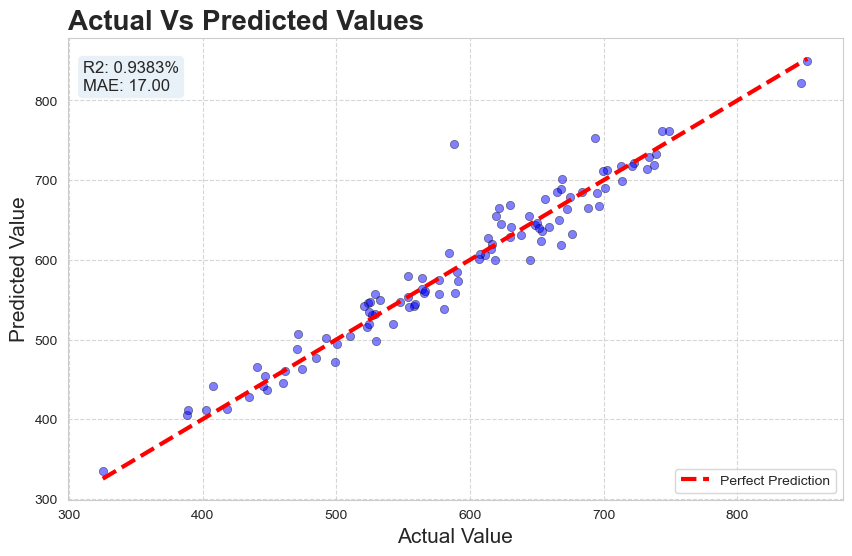

In [36]:
plt.figure(figsize=(10,6))
sns.set_style('whitegrid')

plt.scatter(y1_test,y1_pred,alpha=0.5,color='blue',edgecolors='black',linewidths=0.5)

plt.plot([y1_test.min(), y1_test.max()],
    [y1_test.min(), y1_test.max()],
    linestyle="--",
    linewidth=3,
    label="Perfect Prediction",
    color = "red")

plt.xlabel('Actual Value',fontsize=15)
plt.ylabel("Predicted Value",fontsize=15)
plt.title("Actual Vs Predicted Values",loc='left',fontsize=20,weight='bold')
plt.grid(True,linestyle='--',alpha=0.8)

plt.text(
    0.02, 0.95,
    f"R2: {round(R2_1,4)}%\nMAE: {MAE_1:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle="round", alpha=0.1)
)

plt.legend()
plt.show()

## *Model-2*

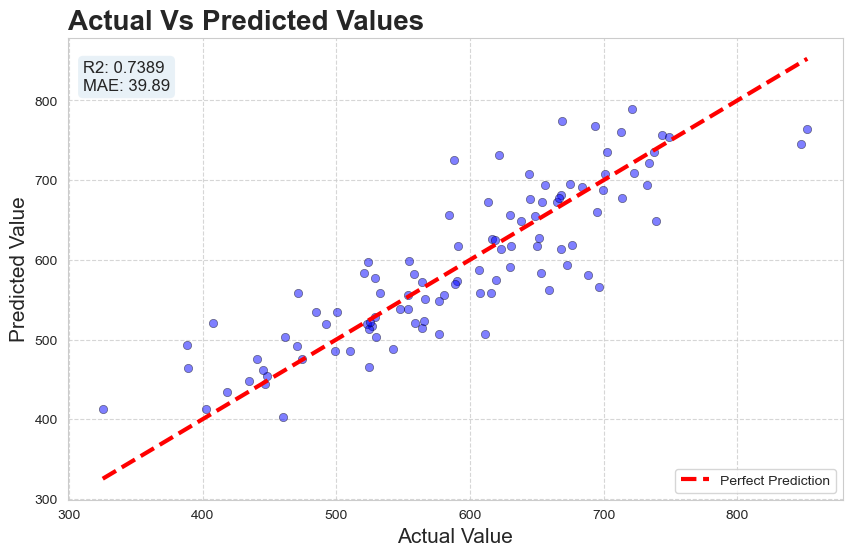

In [35]:
plt.figure(figsize=(10,6))
sns.set_style('whitegrid')

plt.scatter(y2_test,y2_pred,alpha=0.5,color='blue',edgecolors='black',linewidths=0.5)

plt.plot([y2_test.min(), y2_test.max()],
    [y2_test.min(), y2_test.max()],
    linestyle="--",
    linewidth=3,
    label="Perfect Prediction",
    color = "red")

plt.xlabel('Actual Value',fontsize=15)
plt.ylabel("Predicted Value",fontsize=15)
plt.title("Actual Vs Predicted Values",loc='left',fontsize=20,weight='bold')
plt.grid(True,linestyle='--',alpha=0.8)

plt.text(
    0.02, 0.95,
    f"R2: {round(R2_2,4)}\nMAE: {MAE_2:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle="round", alpha=0.1)
)

plt.legend()
plt.show()